# FGADR Segmentation - Visualization

Visualize predictions after 1 epoch:
- Original image
- Ground truth masks (2 channels)
- Predicted masks (2 channels)
- Overlay comparisons

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import json
import segmentation_models_pytorch as smp

# Add parent directory
sys.path.append(str(Path.cwd().parent))

from data_factory.fgadr_multiclass_dataset import FGADRMultiClassDataset, create_fgadr_dataframe

print("Libraries loaded")

Libraries loaded


## Load Model

In [2]:
# Load config
config = {
    'model_name': 'unet',
    'encoder_name': 'efficientnet-b4',
    'num_classes': 2,
    'resolution': 512,
    'checkpoint_path': '../outputs/fgadr_multiclass/checkpoints/best_model.pth'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Create model
model = smp.Unet(
    encoder_name=config['encoder_name'],
    encoder_weights=None,  # Will load from checkpoint
    in_channels=3,
    classes=config['num_classes'],
    activation=None
)

# Load checkpoint
checkpoint = torch.load(config['checkpoint_path'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✓ Model loaded from {config['checkpoint_path']}")
print(f"  Best Val Dice: {checkpoint['val_dice']:.4f}")

Device: cuda
✓ Model loaded from ../outputs/fgadr_multiclass/checkpoints/best_model.pth
  Best Val Dice: 0.2679


## Load Validation Data

In [3]:
# Load splits
with open('fgadr_splits.json', 'r') as f:
    splits = json.load(f)

# Load dataset
df = create_fgadr_dataframe()
val_df = df[df['filename'].isin(splits['val'])].reset_index(drop=True)

# Create validation dataset
val_dataset = FGADRMultiClassDataset(
    dataframe=val_df,
    image_size=(config['resolution'], config['resolution']),
    is_train=False  # No augmentation
)

print(f"✓ Validation dataset: {len(val_dataset)} samples")

✓ FGADR Dataset
  Total images: 1842
  Unique patients: 1842
✓ Validation dataset: 276 samples


## Helper Functions

In [4]:
def denormalize_image(img_tensor):
    """Denormalize image from ImageNet normalization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).cpu().numpy()

def predict(model, image, device):
    """Run inference on a single image"""
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        logits = model(image)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
    return probs.squeeze(0).cpu(), preds.squeeze(0).cpu()

def overlay_mask(image, mask, color, alpha=0.4):
    """Overlay mask on image with given color"""
    overlay = image.copy()
    mask_bool = mask > 0.5
    overlay[mask_bool] = overlay[mask_bool] * (1 - alpha) + np.array(color) * alpha
    return overlay

print("✓ Helper functions defined")

✓ Helper functions defined


## Visualize Predictions

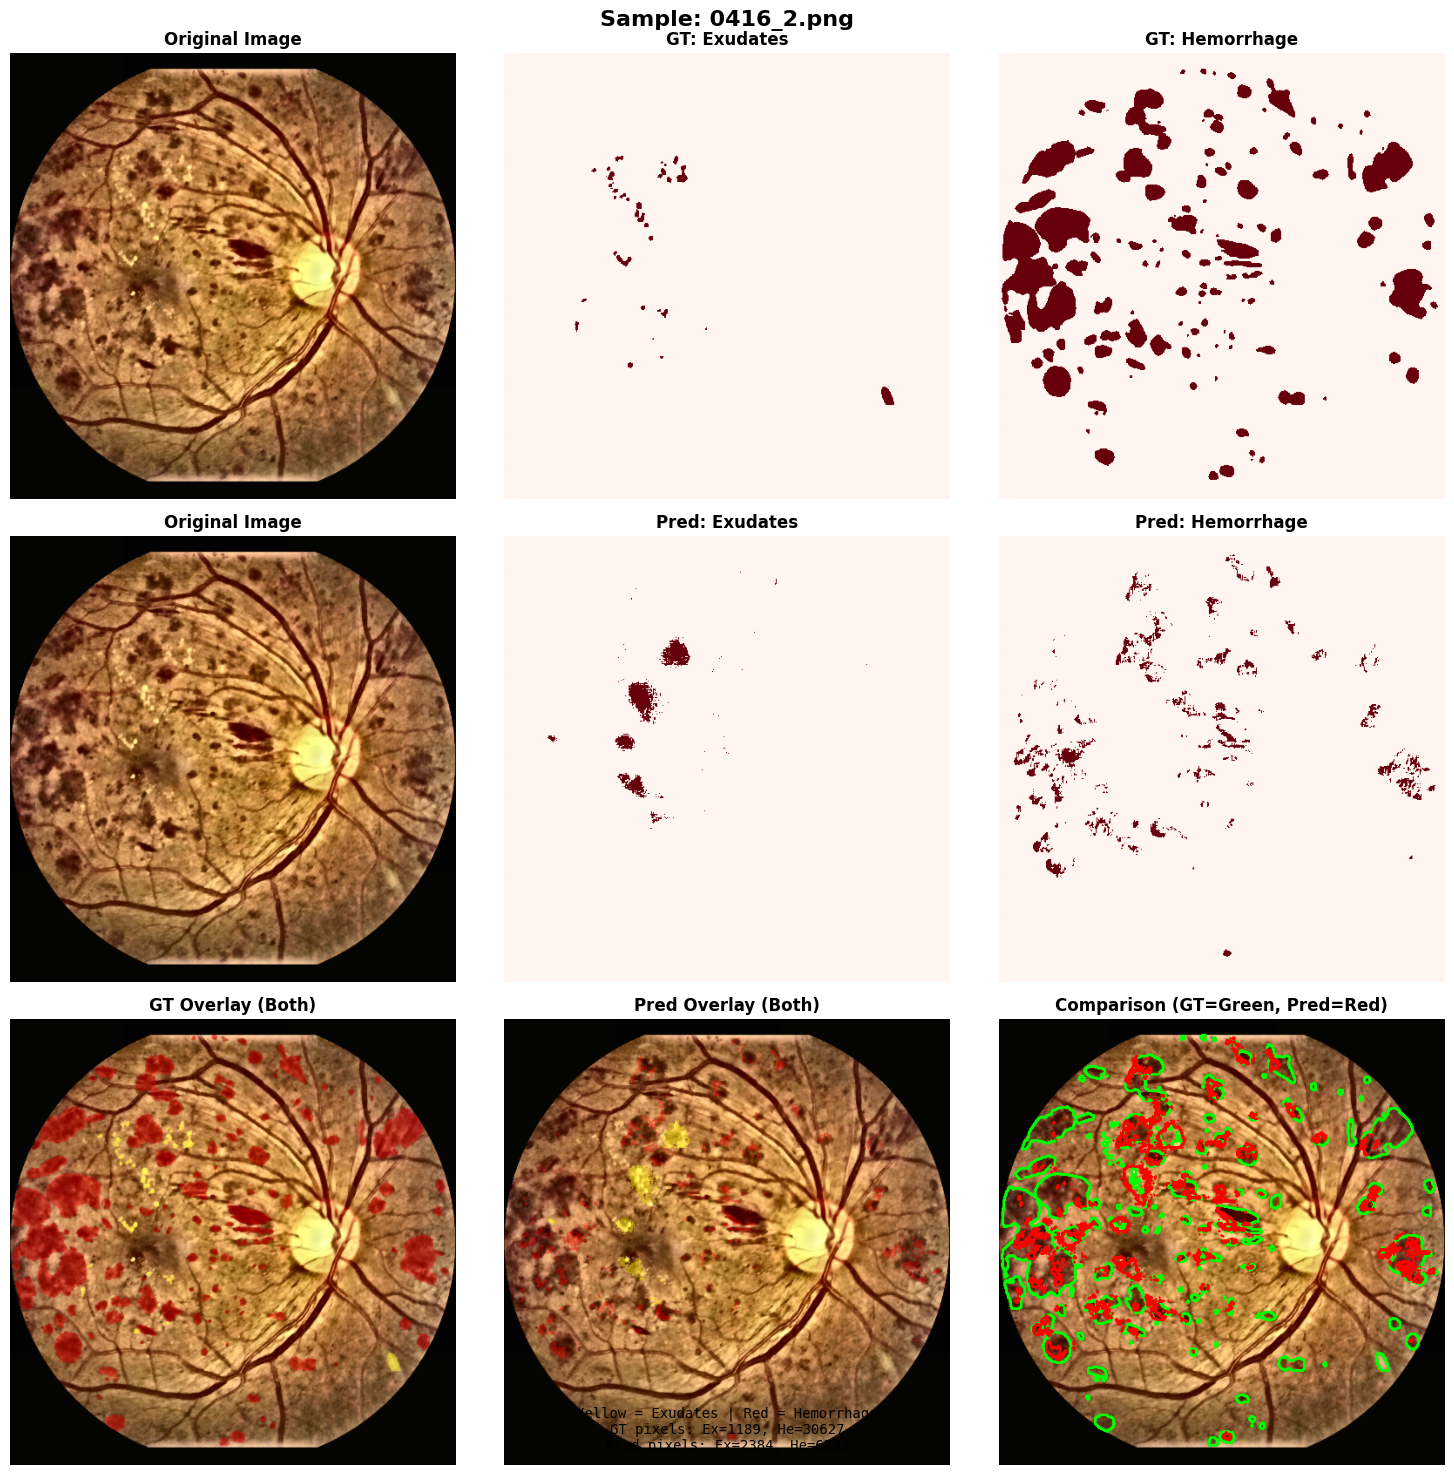

Sample 56 (0416_2.png):
  GT  - Exudates: 1189 px | Hemorrhage: 30627 px
  Pred - Exudates: 2384 px | Hemorrhage: 6292 px



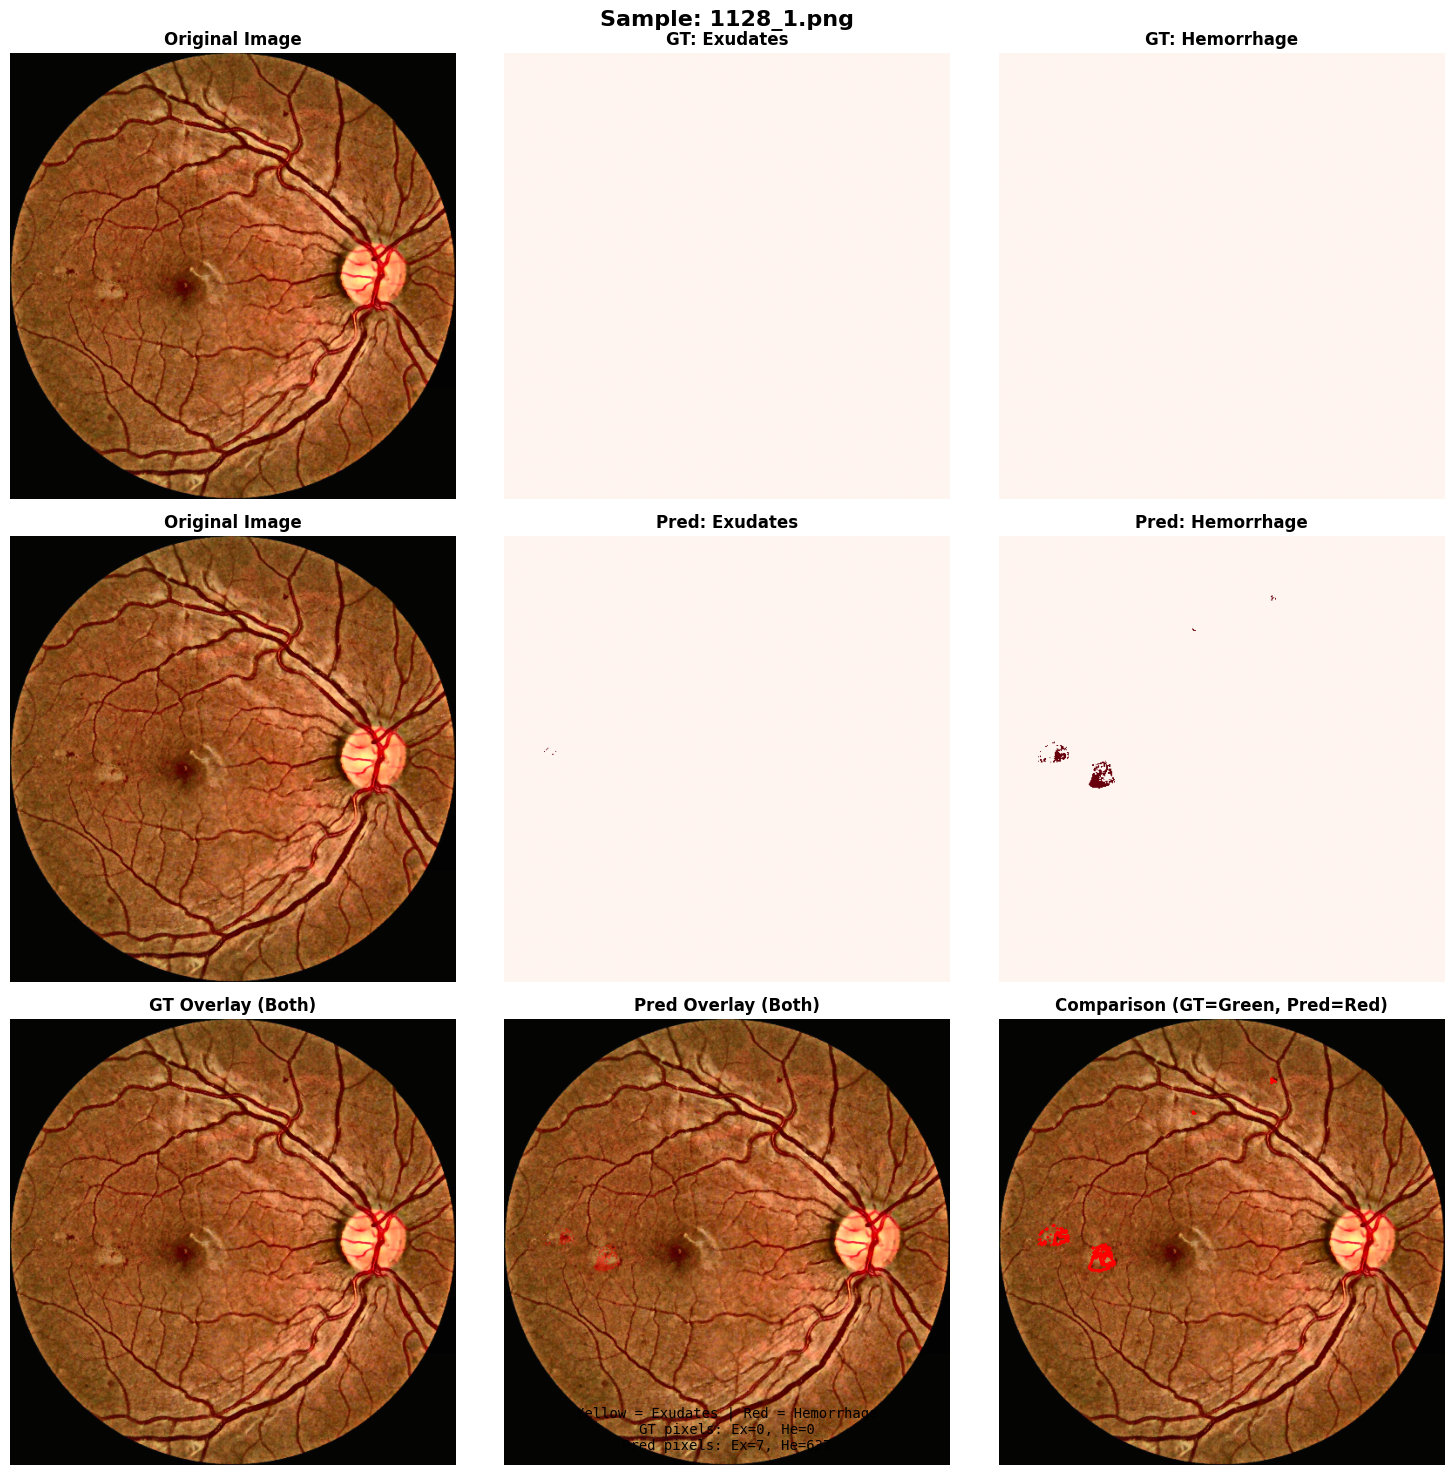

Sample 151 (1128_1.png):
  GT  - Exudates: 0 px | Hemorrhage: 0 px
  Pred - Exudates: 7 px | Hemorrhage: 637 px



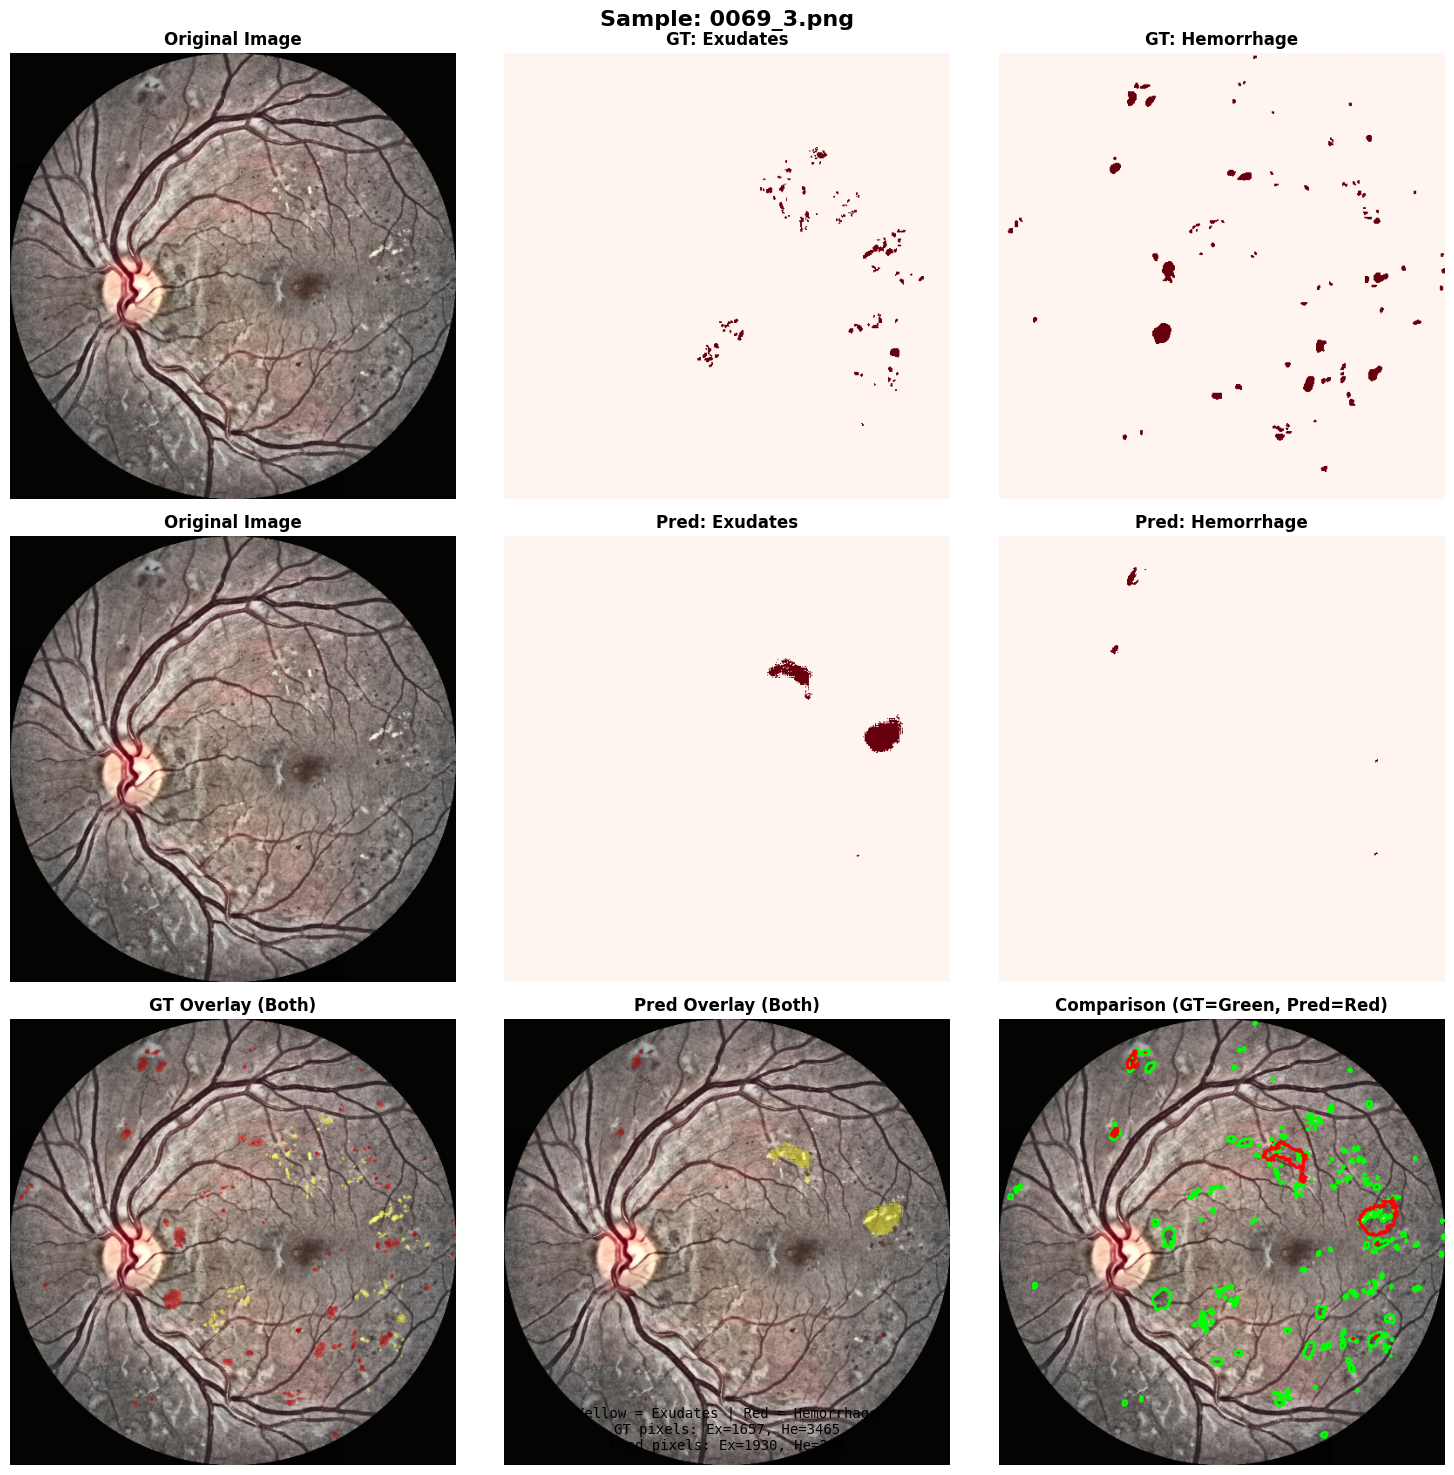

Sample 6 (0069_3.png):
  GT  - Exudates: 1657 px | Hemorrhage: 3465 px
  Pred - Exudates: 1930 px | Hemorrhage: 216 px



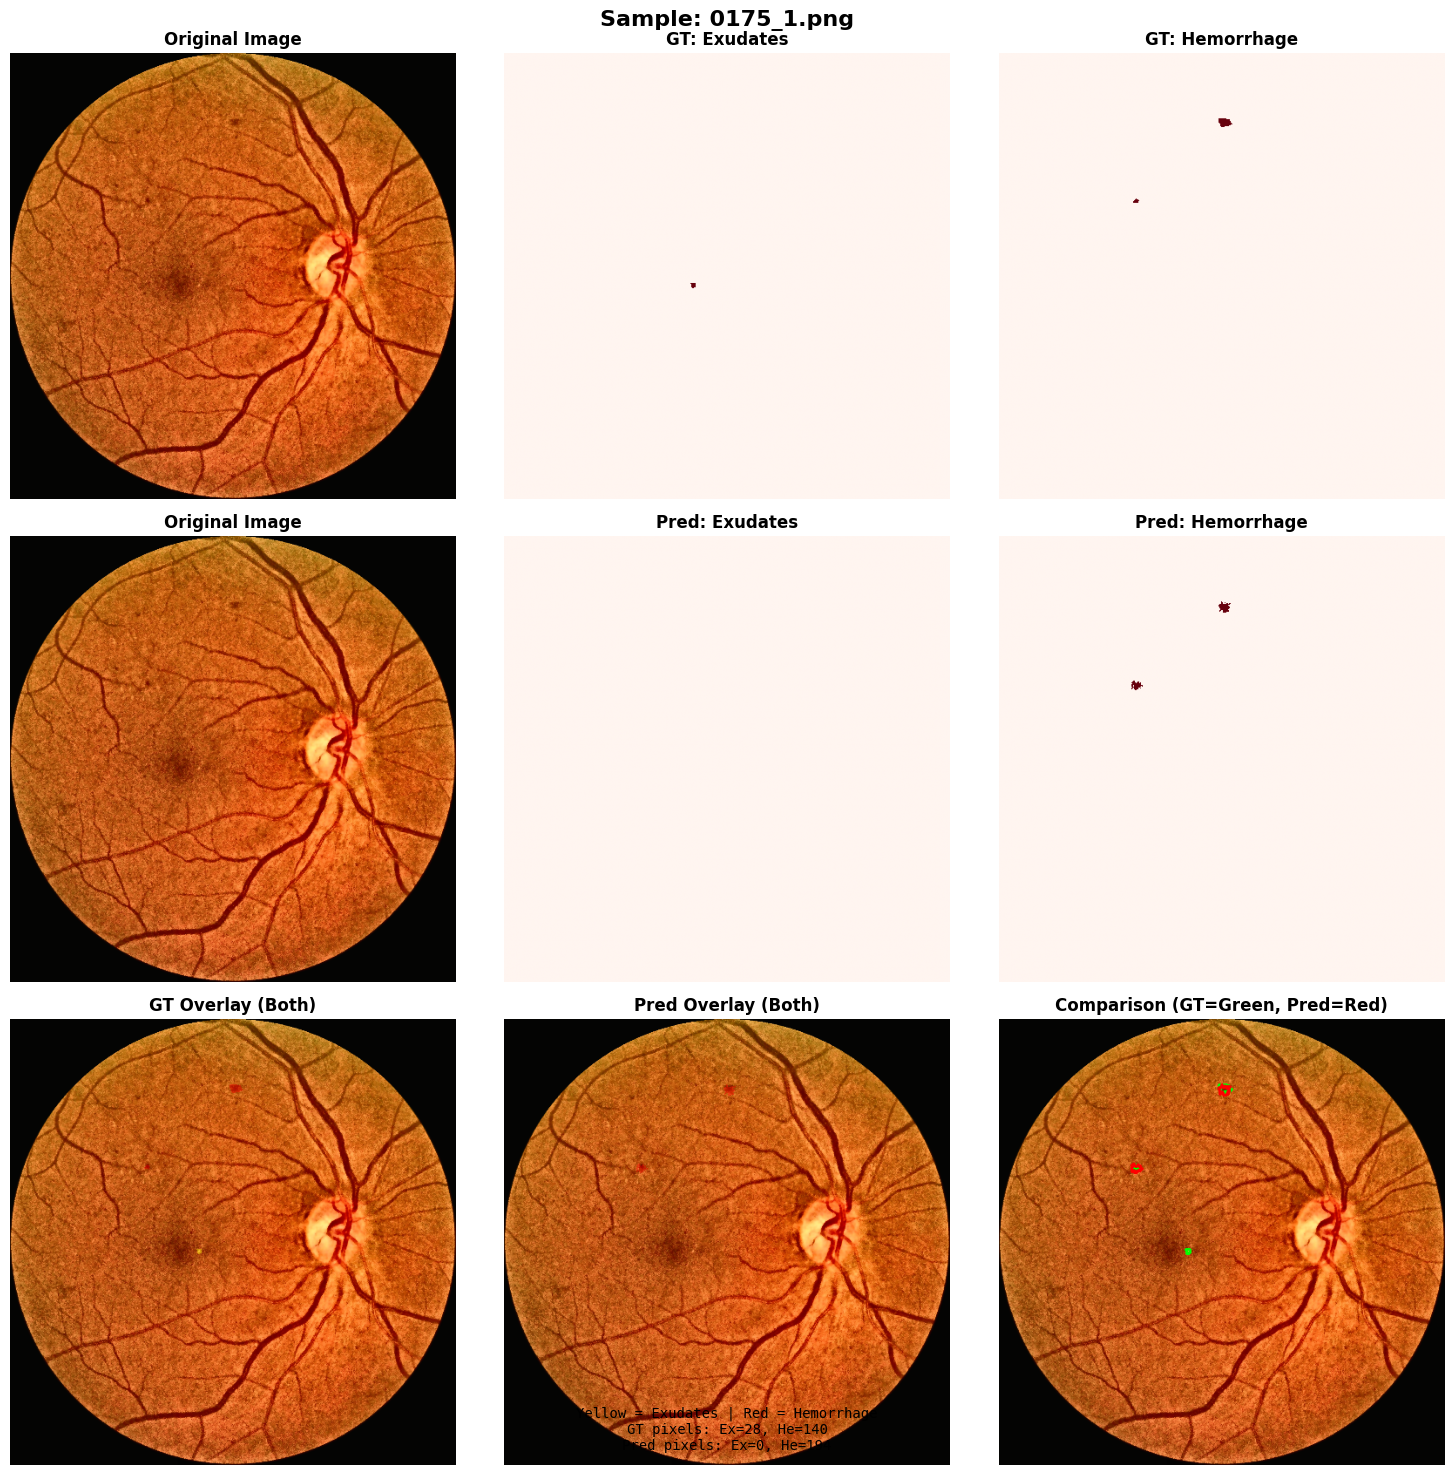

Sample 19 (0175_1.png):
  GT  - Exudates: 28 px | Hemorrhage: 140 px
  Pred - Exudates: 0 px | Hemorrhage: 194 px



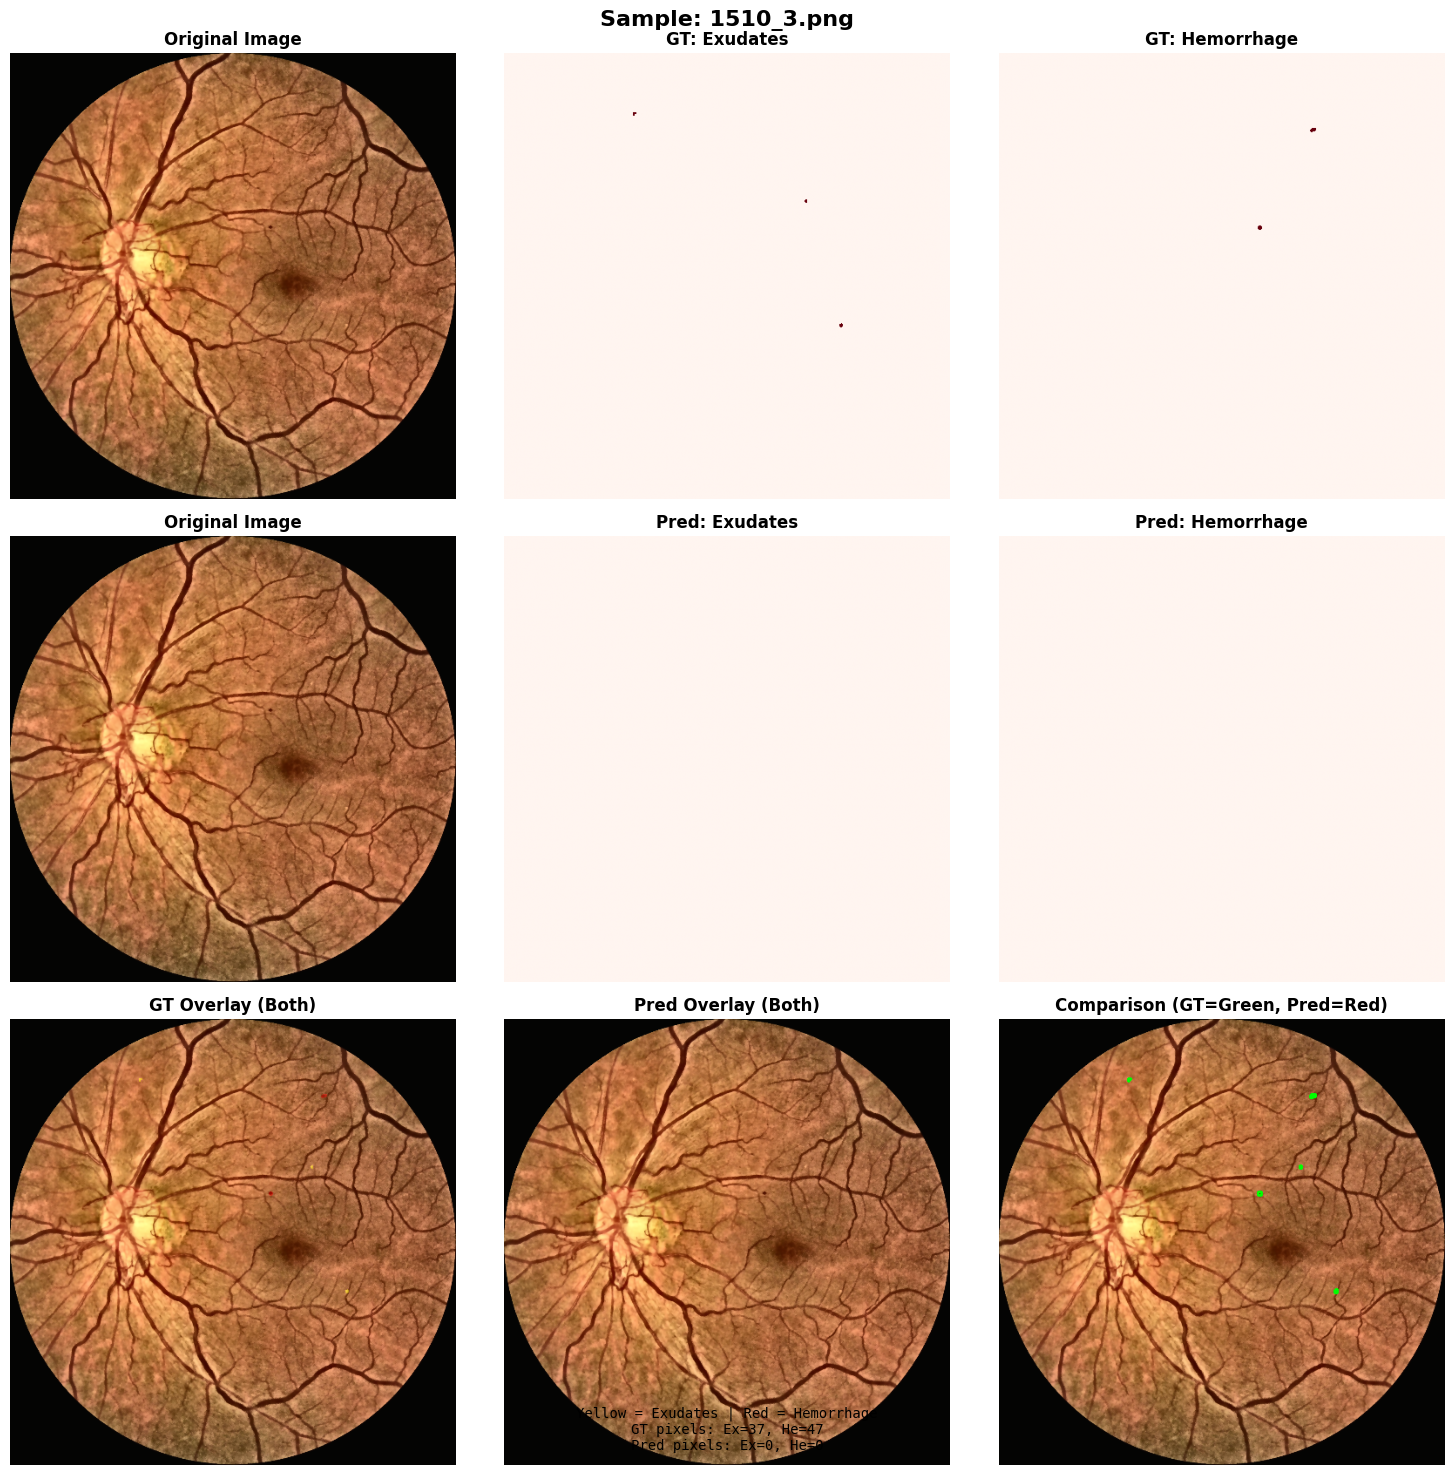

Sample 222 (1510_3.png):
  GT  - Exudates: 37 px | Hemorrhage: 47 px
  Pred - Exudates: 0 px | Hemorrhage: 0 px



In [5]:
# Select random samples
num_samples = 5
indices = np.random.choice(len(val_dataset), num_samples, replace=False)

class_names = ['Exudates', 'Hemorrhage']
colors = [
    [1.0, 1.0, 0.0],  # Yellow for Exudates
    [1.0, 0.0, 0.0]   # Red for Hemorrhage
]

for idx in indices:
    # Load sample
    image, gt_mask = val_dataset[idx]
    filename = val_df.iloc[idx]['filename']
    
    # Get prediction
    probs, pred_mask = predict(model, image, device)
    
    # Denormalize image
    img_display = denormalize_image(image)
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle(f'Sample: {filename}', fontsize=16, fontweight='bold')
    
    # Row 1: Original + GT masks
    axes[0, 0].imshow(img_display)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gt_mask[0], cmap='Reds')
    axes[0, 1].set_title(f'GT: {class_names[0]}', fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(gt_mask[1], cmap='Reds')
    axes[0, 2].set_title(f'GT: {class_names[1]}', fontweight='bold')
    axes[0, 2].axis('off')
    
    # Row 2: Predicted masks
    axes[1, 0].imshow(img_display)
    axes[1, 0].set_title('Original Image', fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(pred_mask[0], cmap='Reds')
    axes[1, 1].set_title(f'Pred: {class_names[0]}', fontweight='bold')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(pred_mask[1], cmap='Reds')
    axes[1, 2].set_title(f'Pred: {class_names[1]}', fontweight='bold')
    axes[1, 2].axis('off')
    
    # Row 3: Overlays
    # GT overlay (both classes)
    gt_overlay = img_display.copy()
    for c_idx, (color, name) in enumerate(zip(colors, class_names)):
        gt_overlay = overlay_mask(gt_overlay, gt_mask[c_idx].numpy(), color, alpha=0.4)
    axes[2, 0].imshow(gt_overlay)
    axes[2, 0].set_title('GT Overlay (Both)', fontweight='bold')
    axes[2, 0].axis('off')
    
    # Pred overlay (both classes)
    pred_overlay = img_display.copy()
    for c_idx, (color, name) in enumerate(zip(colors, class_names)):
        pred_overlay = overlay_mask(pred_overlay, pred_mask[c_idx].numpy(), color, alpha=0.4)
    axes[2, 1].imshow(pred_overlay)
    axes[2, 1].set_title('Pred Overlay (Both)', fontweight='bold')
    axes[2, 1].axis('off')
    
    # Comparison (GT green border, Pred red border)
    comparison = img_display.copy()
    # GT in green contours
    for c_idx in range(2):
        gt_contours = cv2.findContours(
            (gt_mask[c_idx].numpy() > 0.5).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )[0]
        cv2.drawContours(comparison, gt_contours, -1, (0, 1, 0), 2)  # Green
    
    # Pred in red contours
    for c_idx in range(2):
        pred_contours = cv2.findContours(
            (pred_mask[c_idx].numpy() > 0.5).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )[0]
        cv2.drawContours(comparison, pred_contours, -1, (1, 0, 0), 2)  # Red
    
    axes[2, 2].imshow(comparison)
    axes[2, 2].set_title('Comparison (GT=Green, Pred=Red)', fontweight='bold')
    axes[2, 2].axis('off')
    
    # Add legend
    legend_text = f"Yellow = Exudates | Red = Hemorrhage\n"
    legend_text += f"GT pixels: Ex={gt_mask[0].sum():.0f}, He={gt_mask[1].sum():.0f}\n"
    legend_text += f"Pred pixels: Ex={pred_mask[0].sum():.0f}, He={pred_mask[1].sum():.0f}"
    fig.text(0.5, 0.02, legend_text, ha='center', fontsize=10, family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Sample {idx} ({filename}):")
    print(f"  GT  - Exudates: {gt_mask[0].sum():.0f} px | Hemorrhage: {gt_mask[1].sum():.0f} px")
    print(f"  Pred - Exudates: {pred_mask[0].sum():.0f} px | Hemorrhage: {pred_mask[1].sum():.0f} px")
    print()

## Compute Metrics on Full Validation Set

In [6]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def dice_coefficient(pred, target, smooth=1.0):
    """Calculate Dice coefficient"""
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# Create dataloader
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)

dice_scores = [[] for _ in range(2)]  # Per class

print("Computing metrics on validation set...")
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Validating'):
        images = images.to(device)
        masks = masks.to(device)
        
        # Predict
        logits = model(images)
        preds = torch.sigmoid(logits)
        preds_binary = (preds > 0.5).float()
        
        # Calculate per-class Dice
        for c in range(2):
            for b in range(images.size(0)):
                dice = dice_coefficient(preds_binary[b, c], masks[b, c])
                dice_scores[c].append(dice.item())

# Print results
print("\n" + "="*60)
print("VALIDATION METRICS (After 1 Epoch)")
print("="*60)
for c, name in enumerate(class_names):
    mean_dice = np.mean(dice_scores[c])
    std_dice = np.std(dice_scores[c])
    print(f"{name:12s}: Dice = {mean_dice:.4f} ± {std_dice:.4f}")

overall_dice = np.mean([np.mean(dice_scores[c]) for c in range(2)])
print(f"{'Overall':12s}: Dice = {overall_dice:.4f}")
print("="*60)

Computing metrics on validation set...


Validating: 100%|██████████| 35/35 [00:10<00:00,  3.26it/s]


VALIDATION METRICS (After 1 Epoch)
Exudates    : Dice = 0.3074 ± 0.2741
Hemorrhage  : Dice = 0.2284 ± 0.2072
Overall     : Dice = 0.2679
